In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')
sns.set_style('darkgrid')

In [2]:
train = pd.read_csv('train\\train.csv')
test = pd.read_csv('test\\test.csv')

print(train.shape, test.shape)
train.head()

(1458644, 11) (625134, 9)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [3]:
train.info() # смотрим информацию (типы признаков, не нулевые колонки)
train.isna().mean().sort_values(ascending=False).head(20) # смотрим признаки с самыми частыми пропусками

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


id                    0.0
vendor_id             0.0
pickup_datetime       0.0
dropoff_datetime      0.0
passenger_count       0.0
pickup_longitude      0.0
pickup_latitude       0.0
dropoff_longitude     0.0
dropoff_latitude      0.0
store_and_fwd_flag    0.0
trip_duration         0.0
dtype: float64

In [4]:
train.describe(include="all").T # общая сводка по каждому признаку (максимум, минимум, квартили, среднее и т.д.)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,1458644,1458644,id2875421,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vendor_id,1458644.0,NaN,NaN,NaN,1.53495,0.498777,1.0,1.0,2.0,2.0,2.0
pickup_datetime,1458644,1380222,2016-02-09 21:03:38,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dropoff_datetime,1458644,1380377,2016-05-16 19:40:28,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
passenger_count,1458644.0,NaN,NaN,NaN,1.66453,1.314242,0.0,1.0,1.0,2.0,9.0
pickup_longitude,1458644.0,NaN,NaN,NaN,-73.973486,0.070902,-121.933342,-73.991867,-73.981743,-73.967331,-61.335529
pickup_latitude,1458644.0,NaN,NaN,NaN,40.750921,0.032881,34.359695,40.737347,40.754101,40.76836,51.881084
dropoff_longitude,1458644.0,NaN,NaN,NaN,-73.973416,0.070643,-121.933304,-73.991325,-73.979752,-73.963013,-61.335529
dropoff_latitude,1458644.0,NaN,NaN,NaN,40.7518,0.035891,32.181141,40.735885,40.754524,40.76981,43.921028
store_and_fwd_flag,1458644,2,N,1450599,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
train["pickup_datetime"] = pd.to_datetime(train["pickup_datetime"])
train["dropoff_datetime"] = pd.to_datetime(train["dropoff_datetime"])
test["pickup_datetime"] = pd.to_datetime(test["pickup_datetime"])

In [6]:
train.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [7]:
def add_time_features(df):
    dt = df["pickup_datetime"]
    df["pickup_year"] = dt.dt.year
    df["pickup_month"] = dt.dt.month
    df["pickup_day"] = dt.dt.day
    df["pickup_hour"] = dt.dt.hour
    df["pickup_dow"] = dt.dt.dayofweek
    df["pickup_is_weekend"] = (df["pickup_dow"] >= 5).astype(int)
    return df

# Добавляем более удобные и разнообразные временные признаки
train = add_time_features(train)
test  = add_time_features(test)

In [8]:
train

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_year,pickup_month,pickup_day,pickup_hour,pickup_dow,pickup_is_weekend
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,2016,3,14,17,0,0
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,2016,6,12,0,6,1
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,2016,1,19,11,1,0
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,2016,4,6,19,2,0
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,2016,3,26,13,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458639,id2376096,2,2016-04-08 13:31:04,2016-04-08 13:44:02,4,-73.982201,40.745522,-73.994911,40.740170,N,778,2016,4,8,13,4,0
1458640,id1049543,1,2016-01-10 07:35:15,2016-01-10 07:46:10,1,-74.000946,40.747379,-73.970184,40.796547,N,655,2016,1,10,7,6,1
1458641,id2304944,2,2016-04-22 06:57:41,2016-04-22 07:10:25,1,-73.959129,40.768799,-74.004433,40.707371,N,764,2016,4,22,6,4,0
1458642,id2714485,1,2016-01-05 15:56:26,2016-01-05 16:02:39,1,-73.982079,40.749062,-73.974632,40.757107,N,373,2016,1,5,15,1,0


In [9]:
train["trip_duration"].describe()

count    1.458644e+06
mean     9.594923e+02
std      5.237432e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64

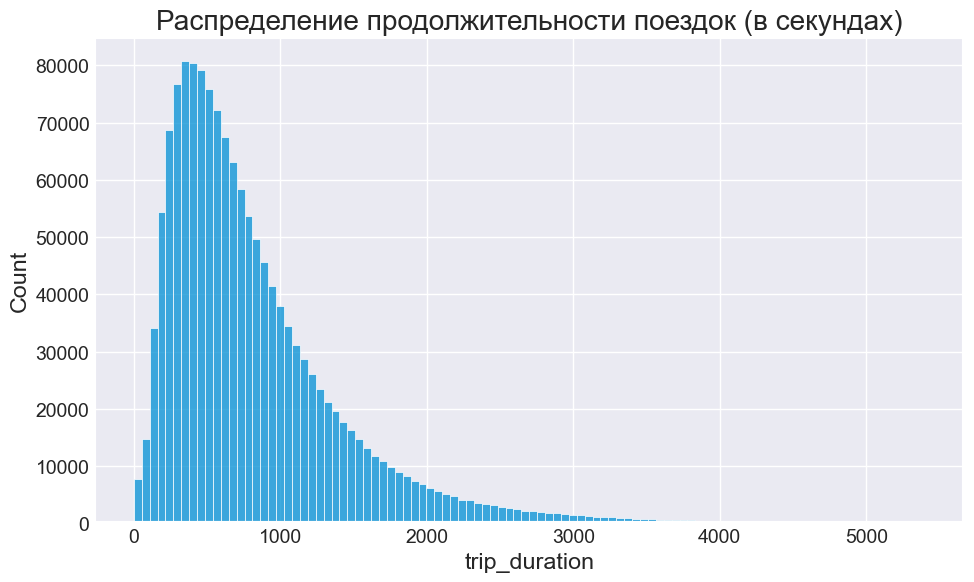

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(train[train["trip_duration"] < 5400]["trip_duration"], bins=100)
plt.title("Распределение продолжительности поездок (в секундах)")
plt.show()

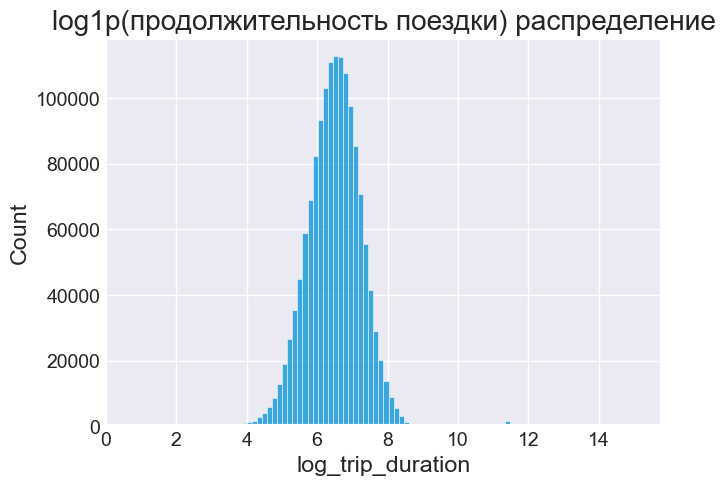

In [11]:
train["log_trip_duration"] = np.log1p(train["trip_duration"]) # логарифмируем данные, чтоб они были 'ближе' друг к другу


plt.figure()
sns.histplot(train["log_trip_duration"], bins=100)
plt.title("log1p(продолжительность поездки) распределение")
plt.show()

# Разбиваем на квантили и уберем выбросы

In [12]:
train["trip_duration"].quantile([0.001, 0.01, 0.1, 0.2, 0.5, 0.99, 0.999])

0.001        7.000
0.010       87.000
0.100      245.000
0.200      348.000
0.500      662.000
0.990     3440.000
0.999    85128.357
Name: trip_duration, dtype: float64

In [13]:
print(f'Сколько останется строк, если удалить поездки короче 2 минут: {len(train) - len(train[train["trip_duration"] <= 120])}')
print(f'Процент от всех поездок: {len(train[train["trip_duration"] <=120])/len(train)*100}')

Сколько останется строк, если удалить поездки короче 2 минут: 1430326
Процент от всех поездок: 1.9413921422910592


In [14]:
print(f'Сколько останется строк, если удалить поездки длинее 3 часов: {len(train) - len(train[train["trip_duration"] >= 3*3600])}')
print(f'Процент от всех поездок: {len(train[train["trip_duration"] >=3*3600])/len(train)*100}')

Сколько останется строк, если удалить поездки длинее 3 часов: 1456532
Процент от всех поездок: 0.14479201230732103


In [15]:
before = len(train)
train = train[(train["trip_duration"] >= 120) & (train["trip_duration"] <= 3*3600)]
print(f"Удаленно: {before - len(train)}, {100-(len(train)/before*100)}%")

Удаленно: 29929, 2.0518371857697986%


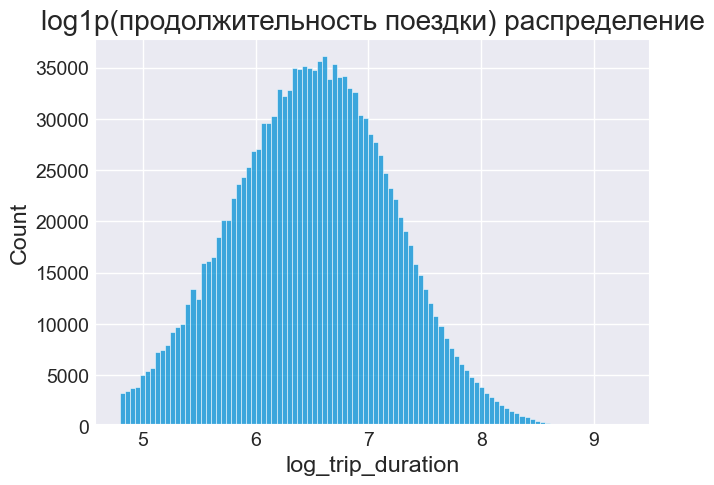

In [16]:
plt.figure()
sns.histplot(train["log_trip_duration"], bins=100)
plt.title("log1p(продолжительность поездки) распределение")
plt.show()

In [17]:
train["passenger_count"].value_counts().sort_index()

passenger_count
0         13
1    1011070
2     206802
3      58931
4      27938
5      76582
6      47378
9          1
Name: count, dtype: int64

In [18]:
train = train[(train["passenger_count"] >= 1) & (train["passenger_count"] <= 6)] # убираем выбросы по количеству пассажиров

In [19]:
cols = ["pickup_longitude","pickup_latitude","dropoff_longitude","dropoff_latitude"]
train[cols].describe()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
count,1.428701e+06,1.428701e+06,1.428701e+06,1.428701e+06
mean,-7.397361e+01,4.075087e+01,-7.397354e+01,4.075176e+01
std,7.101455e-02,3.261596e-02,7.077135e-02,3.571422e-02
min,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01
25%,-7.399190e+01,4.073730e+01,-7.399134e+01,4.073579e+01
50%,-7.398180e+01,4.075401e+01,-7.397980e+01,4.075447e+01
75%,-7.396757e+01,4.076827e+01,-7.396317e+01,4.076969e+01
max,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01


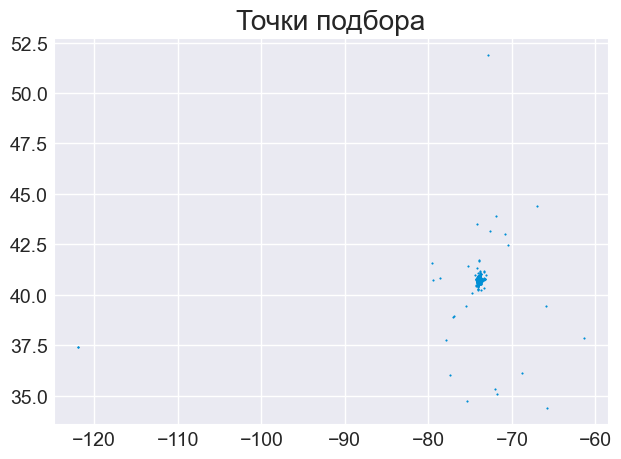

In [20]:
plt.figure()
plt.scatter(train["pickup_longitude"], train["pickup_latitude"], s=1)
plt.title("Точки подбора")
plt.show()

In [21]:
# Уберем выбросы в координатах
train = train[
    (train["pickup_latitude"].between(40.5, 41.0)) &
    (train["dropoff_latitude"].between(40.5, 41.0)) &
    (train["pickup_longitude"].between(-74.3, -73.6)) &
    (train["dropoff_longitude"].between(-74.3, -73.6))
]

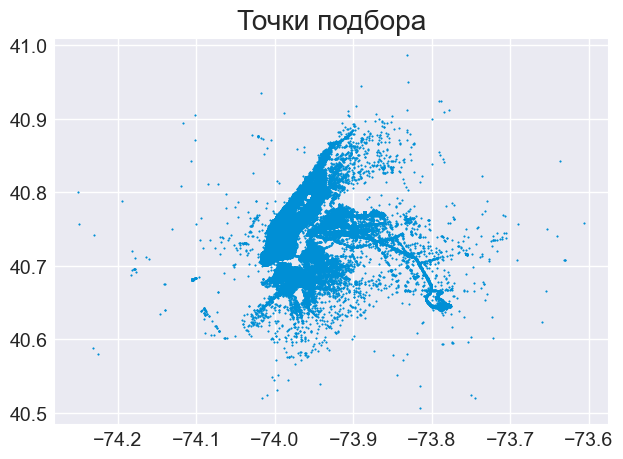

In [22]:
plt.figure()
plt.scatter(train["pickup_longitude"], train["pickup_latitude"], s=1)
plt.title("Точки подбора")
plt.show()

In [23]:
# Функция для вычисления расстояния между
def haversine_np(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c
    return km

In [24]:
train["distance_km"] = haversine_np(
    train["pickup_longitude"], train["pickup_latitude"],
    train["dropoff_longitude"], train["dropoff_latitude"]
)
test["distance_km"] = haversine_np(
    test["pickup_longitude"], test["pickup_latitude"],
    test["dropoff_longitude"], test["dropoff_latitude"]
)

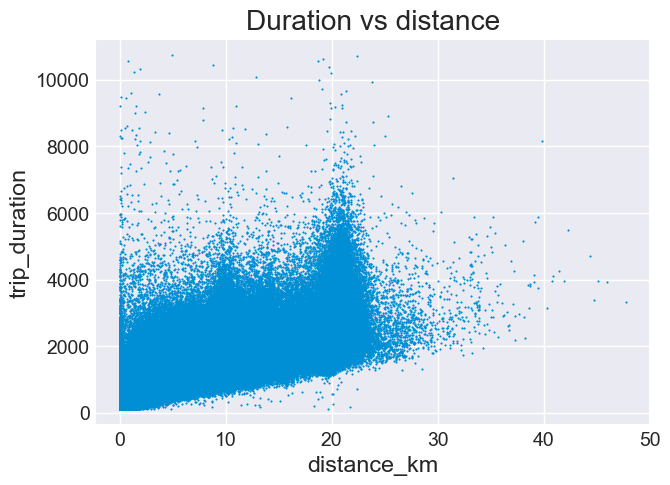

In [25]:
plt.figure()
plt.scatter(train["distance_km"], train["trip_duration"], s=1)
plt.title("Duration vs distance")
plt.xlabel("distance_km")
plt.ylabel("trip_duration")
plt.show()

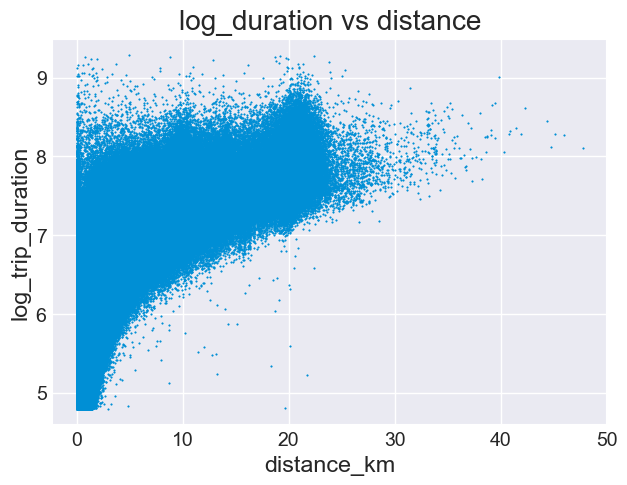

In [26]:
plt.figure()
plt.scatter(train["distance_km"], train["log_trip_duration"], s=1)
plt.title("log_duration vs distance")
plt.xlabel("distance_km")
plt.ylabel("log_trip_duration")
plt.show()

In [27]:
print(train["distance_km"].quantile([0.99, 0.999]))
train = train[train["distance_km"] <= train["distance_km"].quantile(0.999)]

0.990    20.770835
0.999    23.778878
Name: distance_km, dtype: float64


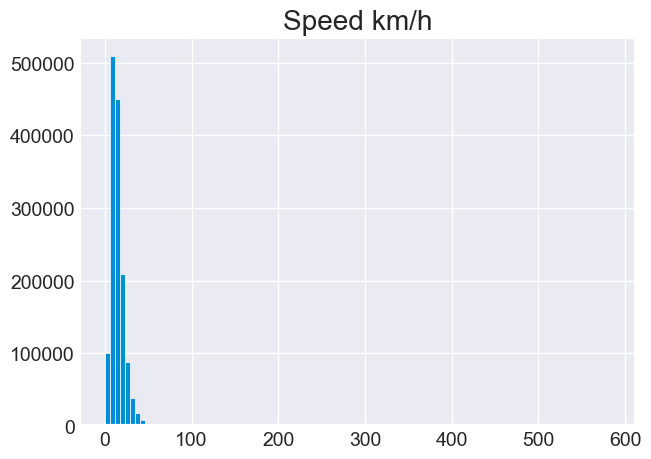

In [28]:
# Вводим новый признак: скорость
train["speed_kmh"] = train["distance_km"] / train["trip_duration"] * 3600


train["speed_kmh"].describe()
plt.figure()
plt.hist(train["speed_kmh"], bins=100)
plt.title("Speed km/h")
plt.show()

In [29]:
# убираем выбросы
train = train[train["speed_kmh"].between(1, 100)]

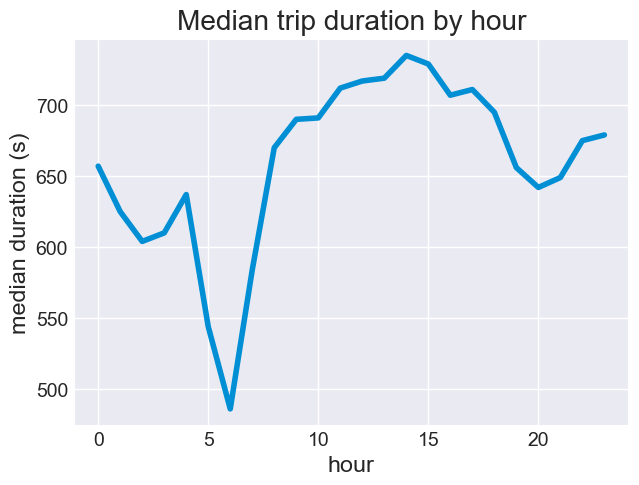

In [30]:
grp = train.groupby("pickup_hour")["trip_duration"].median()

plt.figure()
plt.plot(grp.index, grp.values)
plt.title("Median trip duration by hour")
plt.xlabel("hour")
plt.ylabel("median duration (s)")
plt.show()

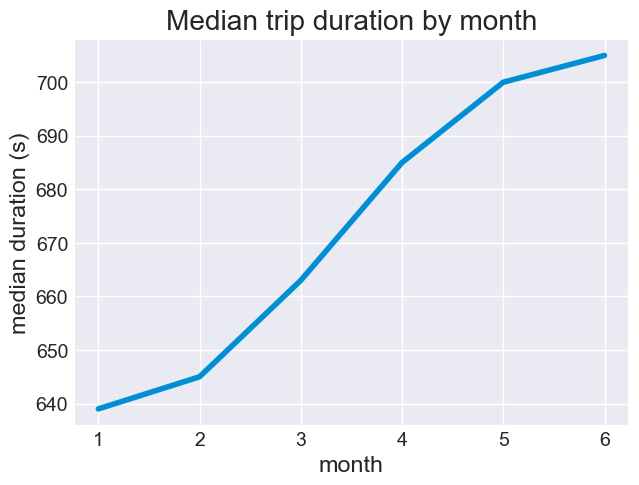

In [31]:
grp = train.groupby("pickup_month")["trip_duration"].median()

plt.figure()
plt.plot(grp.index, grp.values)
plt.title("Median trip duration by month")
plt.xlabel("month")
plt.ylabel("median duration (s)")
plt.show()

In [32]:
train['pickup_month'].value_counts()

pickup_month
3    249403
4    245002
5    241910
2    231788
6    228056
1    223224
Name: count, dtype: int64

In [33]:
train.groupby("pickup_month")["trip_duration"].median()

pickup_month
1    639.0
2    645.0
3    663.0
4    685.0
5    700.0
6    705.0
Name: trip_duration, dtype: float64

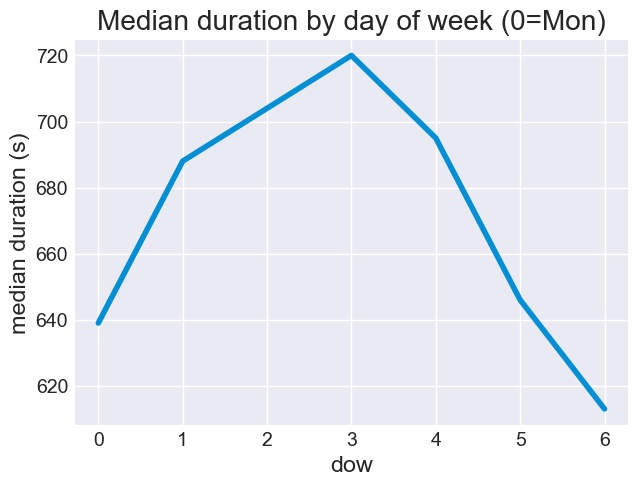

In [34]:
grp = train.groupby("pickup_dow")["trip_duration"].median()

plt.figure()
plt.plot(grp.index, grp.values)
plt.title("Median duration by day of week (0=Mon)")
plt.xlabel("dow")
plt.ylabel("median duration (s)")
plt.show()

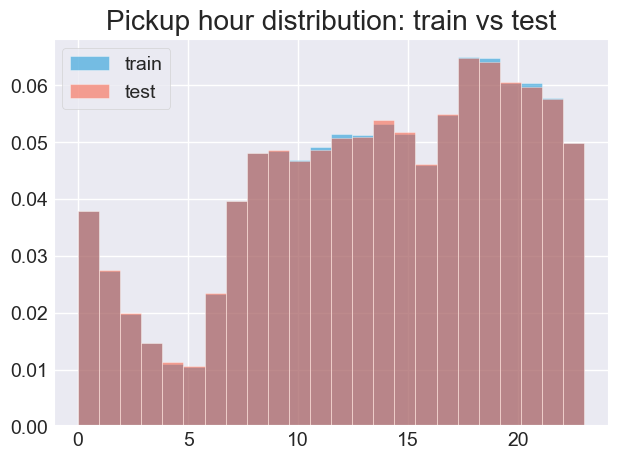

In [35]:
plt.figure()
plt.hist(train["pickup_hour"], bins=24, alpha=0.5, density=True, label="train")
plt.hist(test["pickup_hour"], bins=24, alpha=0.5, density=True, label="test")
plt.legend()
plt.title("Pickup hour distribution: train vs test")
plt.show()

In [36]:
train["store_and_fwd_flag"].value_counts(dropna=False)

store_and_fwd_flag
N    1411621
Y       7762
Name: count, dtype: int64

In [37]:
train.groupby("store_and_fwd_flag")["trip_duration"].median()

store_and_fwd_flag
N    672.0
Y    836.0
Name: trip_duration, dtype: float64

In [38]:
train["vendor_id"].value_counts()

vendor_id
2    758500
1    660883
Name: count, dtype: int64

In [39]:
train.groupby("vendor_id")["trip_duration"].median()

vendor_id
1    670.0
2    674.0
Name: trip_duration, dtype: float64

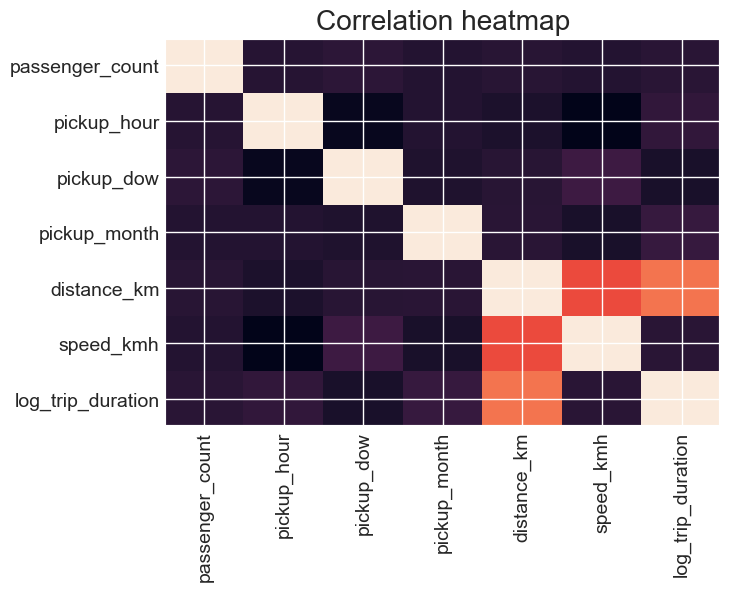

In [40]:
# Построим матрицу корреляции числовых признаков
num_cols = [
    "passenger_count","pickup_hour","pickup_dow","pickup_month",
    "distance_km","speed_kmh"
]
corr = train[num_cols + ["log_trip_duration"]].corr()

plt.figure()
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation heatmap")
plt.show()

# Кластеризация

Добавим кластеризацию, чтобы модель понимала, в каком районе поездки занимают меньше времени, а в каком больше

In [41]:
train = train.sort_values("pickup_datetime")
y_log = train["log_trip_duration"]

split_idx = int(len(train) * 0.8)

X_tr = train.iloc[:split_idx]
X_val = train.iloc[split_idx:]
y_tr = y_log.iloc[:split_idx]
y_val = y_log.iloc[split_idx:]

In [42]:
"""y_log = train["log_trip_duration"]
X_tr, X_val, y_tr, y_val = train_test_split(
    train, y_log, test_size=0.2, random_state=42
)"""

'y_log = train["log_trip_duration"]\nX_tr, X_val, y_tr, y_val = train_test_split(\n    train, y_log, test_size=0.2, random_state=42\n)'

In [43]:
from sklearn.cluster import KMeans

coords = np.vstack((
    X_tr[["pickup_latitude", "pickup_longitude"]].values,
    X_tr[["dropoff_latitude", "dropoff_longitude"]].values
))

In [44]:
kmeans = KMeans(n_clusters=100, random_state=42)
kmeans.fit(coords)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",100
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [45]:
X_tr["pickup_cluster"] = kmeans.predict(
    X_tr[["pickup_latitude", "pickup_longitude"]]
)

X_tr["dropoff_cluster"] = kmeans.predict(
    X_tr[["dropoff_latitude", "dropoff_longitude"]]
)

In [46]:
X_val["pickup_cluster"] = kmeans.predict(
    X_val[["pickup_latitude", "pickup_longitude"]]
)

X_val["dropoff_cluster"] = kmeans.predict(
    X_val[["dropoff_latitude", "dropoff_longitude"]]
)

In [47]:
test["pickup_cluster"] = kmeans.predict(
    test[["pickup_latitude","pickup_longitude"]]
)

test["dropoff_cluster"] = kmeans.predict(
    test[["dropoff_latitude","dropoff_longitude"]]
)

In [48]:
pickup_cluster_speed = X_tr.groupby("pickup_cluster")["speed_kmh"].mean()
pickup_cluster_speed.sort_values()

pickup_cluster
49    12.216667
21    12.231074
93    12.327905
50    12.637376
6     12.653593
        ...    
4     27.818915
62    28.655370
58    29.090738
99    31.577226
96    34.824507
Name: speed_kmh, Length: 100, dtype: float64

In [49]:
X_tr["pickup_cluster_speed"] = X_tr["pickup_cluster"].map(pickup_cluster_speed)
X_val["pickup_cluster_speed"] = X_val["pickup_cluster"].map(pickup_cluster_speed)
test["pickup_cluster_speed"] = test["pickup_cluster"].map(pickup_cluster_speed)

In [50]:
dropoff_cluster_speed = X_tr.groupby("dropoff_cluster")["speed_kmh"].mean()
X_tr["dropoff_cluster_speed"] = X_tr["dropoff_cluster"].map(dropoff_cluster_speed)
X_val["dropoff_cluster_speed"] = X_val["dropoff_cluster"].map(dropoff_cluster_speed)
test["dropoff_cluster_speed"] = test["dropoff_cluster"].map(dropoff_cluster_speed)

In [51]:
X_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1135506 entries, 96469 to 805162
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   id                     1135506 non-null  object        
 1   vendor_id              1135506 non-null  int64         
 2   pickup_datetime        1135506 non-null  datetime64[ns]
 3   dropoff_datetime       1135506 non-null  datetime64[ns]
 4   passenger_count        1135506 non-null  int64         
 5   pickup_longitude       1135506 non-null  float64       
 6   pickup_latitude        1135506 non-null  float64       
 7   dropoff_longitude      1135506 non-null  float64       
 8   dropoff_latitude       1135506 non-null  float64       
 9   store_and_fwd_flag     1135506 non-null  object        
 10  trip_duration          1135506 non-null  int64         
 11  pickup_year            1135506 non-null  int32         
 12  pickup_month           1135506

# Подготовка данных и обучение модели

In [52]:
use=['vendor_id', 'pickup_is_weekend', 'pickup_hour',
     'pickup_dow', 'pickup_month', 'pickup_day', 'distance_km',
     'passenger_count', 'store_and_fwd_flag',
     'pickup_cluster', 'dropoff_cluster']
unuse = []

In [53]:
X_tr= X_tr[use]
X_val= X_val[use]
if "store_and_fwd_flag" in X_tr.columns:
    X_tr["store_and_fwd_flag"] = X_tr["store_and_fwd_flag"].map({"N": 0, "Y": 1}).astype("int8")
X_tr.info()
if "store_and_fwd_flag" in X_val.columns:
    X_val["store_and_fwd_flag"] = X_val["store_and_fwd_flag"].map({"N": 0, "Y": 1}).astype("int8")
X_val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1135506 entries, 96469 to 805162
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   vendor_id           1135506 non-null  int64  
 1   pickup_is_weekend   1135506 non-null  int64  
 2   pickup_hour         1135506 non-null  int32  
 3   pickup_dow          1135506 non-null  int32  
 4   pickup_month        1135506 non-null  int32  
 5   pickup_day          1135506 non-null  int32  
 6   distance_km         1135506 non-null  float64
 7   passenger_count     1135506 non-null  int64  
 8   store_and_fwd_flag  1135506 non-null  int8   
 9   pickup_cluster      1135506 non-null  int32  
 10  dropoff_cluster     1135506 non-null  int32  
dtypes: float64(1), int32(6), int64(3), int8(1)
memory usage: 70.4 MB
<class 'pandas.core.frame.DataFrame'>
Index: 283877 entries, 958978 to 500524
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dty

In [57]:
X_test = test[use]
if "store_and_fwd_flag" in X_test.columns:
    X_test["store_and_fwd_flag"] = X_test["store_and_fwd_flag"].map({"N": 0, "Y": 1}).astype("int8")
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625134 entries, 0 to 625133
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   vendor_id           625134 non-null  int64  
 1   pickup_is_weekend   625134 non-null  int64  
 2   pickup_hour         625134 non-null  int32  
 3   pickup_dow          625134 non-null  int32  
 4   pickup_month        625134 non-null  int32  
 5   pickup_day          625134 non-null  int32  
 6   distance_km         625134 non-null  float64
 7   passenger_count     625134 non-null  int64  
 8   store_and_fwd_flag  625134 non-null  int8   
 9   pickup_cluster      625134 non-null  int32  
 10  dropoff_cluster     625134 non-null  int32  
dtypes: float64(1), int32(6), int64(3), int8(1)
memory usage: 34.0 MB


In [58]:
import lightgbm as lgb

model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=5000,
    learning_rate=0.03,

    # контролируем сложность
    num_leaves=64,
    max_depth=8,
    min_child_samples=100,

    # стохастика (снижает переобучение)
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,

    # регуляризация
    reg_alpha=0.5,   # L1
    reg_lambda=1.0,  # L2
    min_split_gain=0.0,

    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse",
    callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018554 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 532
[LightGBM] [Info] Number of data points in the train set: 1135506, number of used features: 11
[LightGBM] [Info] Start training from score 6.493280


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,8
,learning_rate,0.03
,n_estimators,5000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,100


In [59]:
pred_log = model.predict(X_val)

In [60]:
y_val

958978     5.549076
300295     6.522093
1452235    6.641182
446399     6.040255
156422     6.030685
             ...   
853710     6.159095
419031     6.626718
1008720    7.842671
405743     7.274480
500524     7.867106
Name: log_trip_duration, Length: 283877, dtype: float64

In [61]:
from sklearn.metrics import mean_squared_log_error, mean_squared_error

pred = np.expm1(pred_log)
true = np.expm1(y_val)
rmsle = np.sqrt(mean_squared_log_error(true, pred))
print(rmsle)

0.3243805939324465


In [62]:
train_score = np.sqrt(mean_squared_error(y_tr, model.predict(X_tr)))
val_score = np.sqrt(mean_squared_error(y_val, model.predict(X_val)))

print("Train:", train_score)
print("Val:", val_score)

Train: 0.2939556458328569
Val: 0.3243805939324465


In [63]:
pred_test_log = model.predict(X_test)
pred_test = np.expm1(pred_test_log)  # обратно из log1p
pred_test = np.clip(pred_test, 0, None)

In [64]:
import joblib, json

joblib.dump(model, "artifacts/model.joblib")
joblib.dump(kmeans, "artifacts/kmeans.joblib")  # если есть

with open("artifacts/feature_cols.json", "w", encoding="utf-8") as f:
    json.dump(use, f, ensure_ascii=False, indent=2)